In [32]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
import psycopg2
# Connect to server
conn = psycopg2.connect(
    dbname="Banking_Case",   # your database name
    user="postgres",         # your username
    password="Asim$282003",   # your password
    host="localhost",        # same as pgAdmin connection
    port=5432                # default PostgreSQL port
)


In [34]:
query = "SELECT * FROM customer;"

In [35]:
df = pd.read_sql(query, conn)

C:\Users\shaik\AppData\Local\Temp\ipykernel_31676\1168034203.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [36]:
conn.close()

In [37]:
df.head()

,clientid,name,age,locationid,joinedbank,bankingcontact,nationality,occupation,feestructure,loyaltyclassification,...,bankdeposits,checkingaccounts,savingaccounts,foreigncurrencyaccount,businesslending,propertiesowned,riskweighting,brid,genderid,iaid
0,IND81288,Raymond Mills,24,34324,2019-05-06,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,2001-12-10,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,2010-01-25,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,2019-03-28,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,2012-07-20,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


In [38]:
df.shape

(3000, 25)

In [39]:
df.isnull().sum()

clientid                  0
name                      0
age                       0
locationid                0
joinedbank                0
bankingcontact            0
nationality               0
occupation                0
feestructure              0
loyaltyclassification     0
estimatedincome           0
superannuationsavings     0
amountofcreditcards       0
creditcardbalance         0
bankloans                 0
bankdeposits              0
checkingaccounts          0
savingaccounts            0
foreigncurrencyaccount    0
businesslending           0
propertiesowned           0
riskweighting             0
brid                      0
genderid                  0
iaid                      0
dtype: int64

In [40]:
# Generate descriptive statistics for the dataframe

df.describe()

,age,estimatedincome,superannuationsavings,amountofcreditcards,creditcardbalance,bankloans,bankdeposits,checkingaccounts,savingaccounts,foreigncurrencyaccount,businesslending,propertiesowned,riskweighting,brid,genderid,iaid
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,51.039667,171305.034263,25531.599673,1.463667,3176.206943,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529993,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333
std,19.854760,111935.808209,16259.950770,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924010,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242
min,17.000000,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542500,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190000,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,69.000000,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.392500,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,522330.260000,75963.900000,3.000000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000


In [41]:
df.rename(columns={
    'clientid': 'client_id',
    'name': 'name',
    'age': 'age',
    'locationid': 'location_id',
    'joinedbank': 'joined_bank',
    'bankingcontact': 'banking_contact',
    'nationality': 'nationality',
    'occupation': 'occupation',
    'feestructure': 'fee_structure',
    'loyaltyclassification': 'loyalty_classification',
    'estimatedincome': 'estimated_income',
    'superannuationsavings': 'superannuation_savings',
    'amountofcreditcards': 'amount_of_credit_cards',
    'creditcardbalance': 'credit_card_balance',
    'bankloans': 'bank_loans',
    'bankdeposits': 'bank_deposits',
    'checkingaccounts': 'checking_accounts',
    'savingaccounts': 'saving_accounts',
    'foreigncurrencyaccount': 'foreign_currency_account',
    'businesslending': 'business_lending',
    'propertiesowned': 'properties_owned',
    'riskweighting': 'risk_weighting',
    'brid': 'br_id',
    'genderid': 'gender_id',
    'iaid': 'ia_id'
}, inplace=True)


In [42]:
df.columns

Index(['client_id', 'name', 'age', 'location_id', 'joined_bank',
       'banking_contact', 'nationality', 'occupation', 'fee_structure',
       'loyalty_classification', 'estimated_income', 'superannuation_savings',
       'amount_of_credit_cards', 'credit_card_balance', 'bank_loans',
       'bank_deposits', 'checking_accounts', 'saving_accounts',
       'foreign_currency_account', 'business_lending', 'properties_owned',
       'risk_weighting', 'br_id', 'gender_id', 'ia_id'],
      dtype='object')

In [43]:
df['estimated_income'].min()

15919.48

<Axes: xlabel='income_band'>

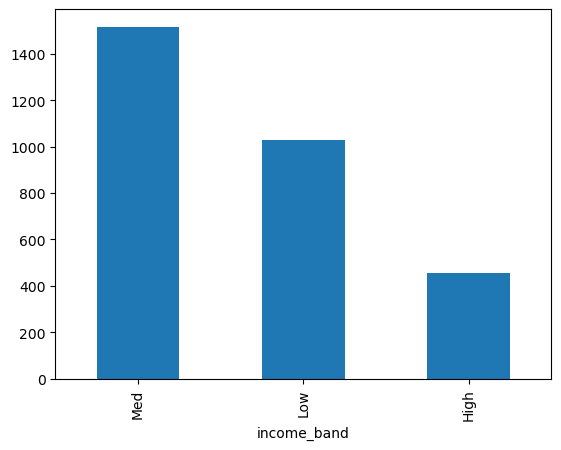

In [44]:
# Categorize continuous income values into Low, Med, High groups

# Define income ranges (bins) :- 0–100000 → Low, 100000–300000 → Med, 300000+ → High

bins = [0,100000,300000,float('inf')]
labels = ['Low','Med','High']

# Categorize 'estimated_income' into bands using pd.cut
# right=False → upper bound excluded (e.g. 100000 goes to 'Med')

df['income_band'] = pd.cut(df['estimated_income'], bins=bins, labels=labels, right=False)

# Plot a bar chart showing how many customers fall into each income band

df['income_band'].value_counts().plot(kind='bar')

In [45]:
# Examine the distribution of unique cataegories in categorical columns

categorical_cols=df[[ 'nationality', 'occupation', 'fee_structure','loyalty_classification',
                      'amount_of_credit_cards','properties_owned','risk_weighting', 
                      'br_id', 'gender_id', 'ia_id','income_band']].columns

for col in categorical_cols:
    print(f"Value Counts for '{col}':")
    display(df[col].value_counts())

Value Counts for 'nationality':


nationality
European      1309
Asian          754
American       507
Australian     254
African        176
Name: count, dtype: int64

Value Counts for 'occupation':


occupation
Structural Analysis Engineer    28
Associate Professor             28
Recruiter                       25
Human Resources Manager         24
Account Coordinator             24
                                ..
Office Assistant IV              8
Automation Specialist I          7
Computer Systems Analyst I       6
Developer III                    5
Senior Sales Associate           4
Name: count, Length: 195, dtype: int64

Value Counts for 'fee_structure':


...

gender_id
2    1512
1    1488
Name: count, dtype: int64

Value Counts for 'ia_id':


ia_id
1     177
3     177
4     177
8     177
2     177
11    176
15    176
14    176
13    176
12    176
10    176
9     176
7      89
6      89
5      89
16     88
17     88
18     88
19     88
20     88
21     88
22     88
Name: count, dtype: int64

Value Counts for 'income_band':


income_band
Med     1517
Low     1027
High     456
Name: count, dtype: int64

## Univariate Analysis

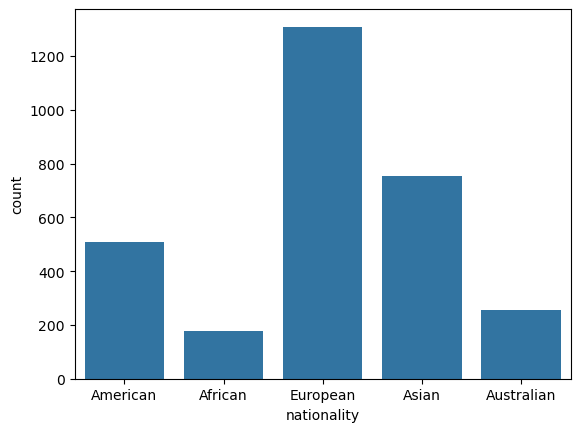

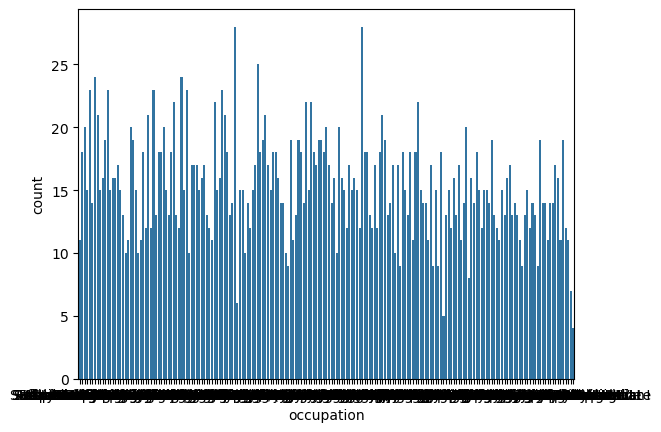

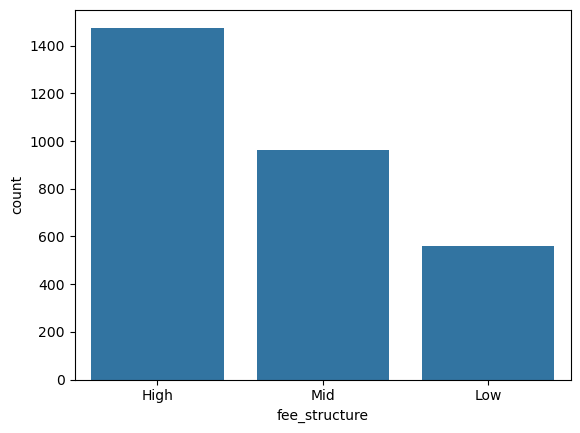

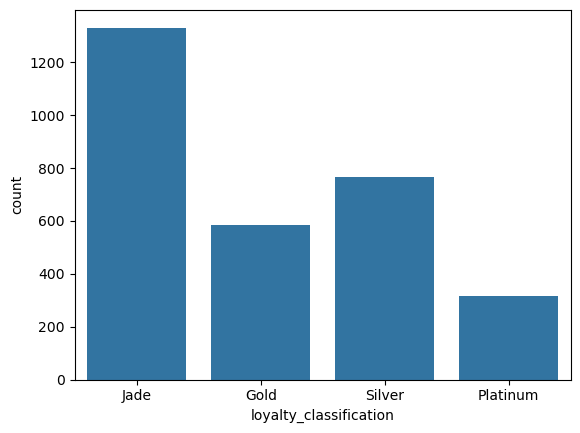

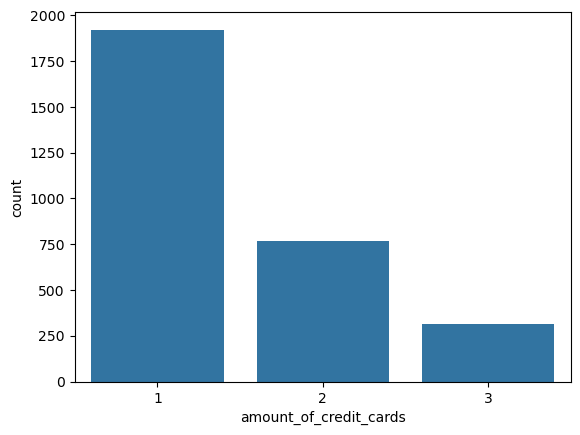

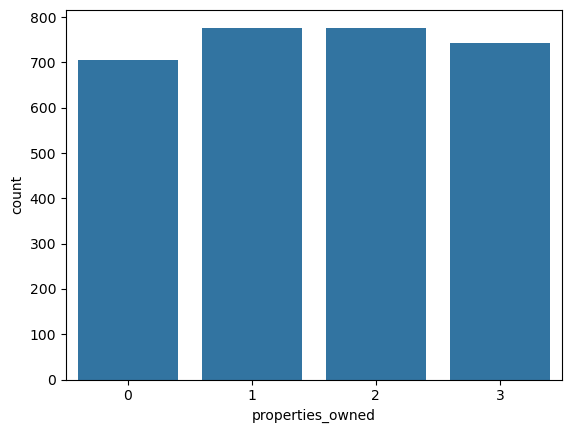

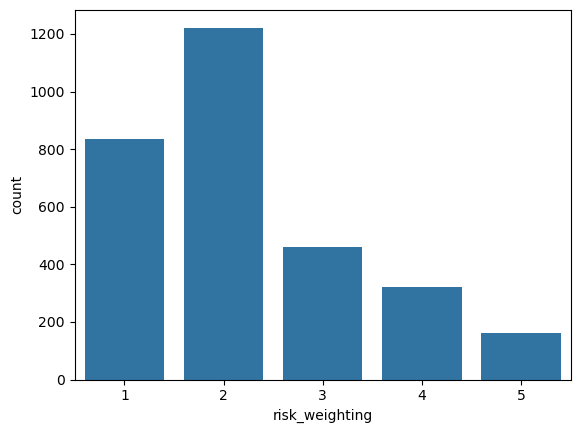

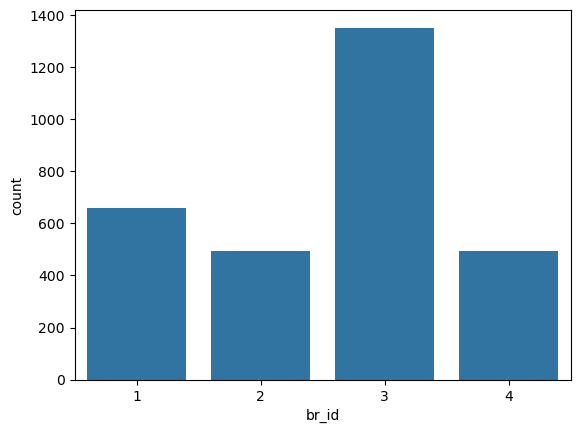

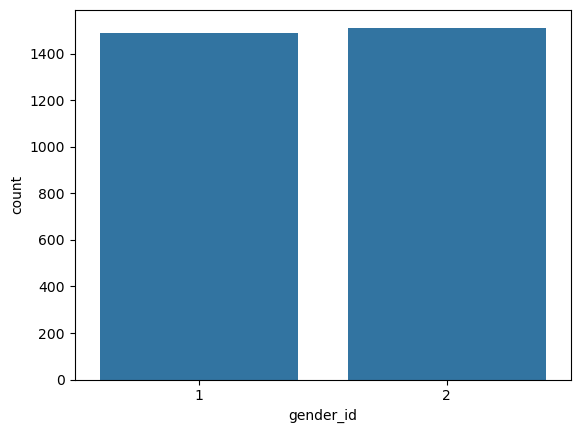

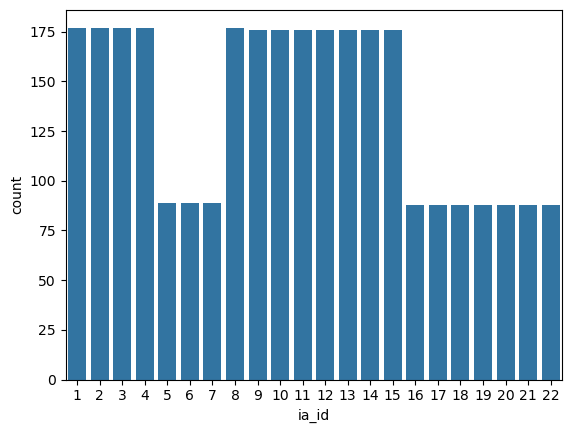

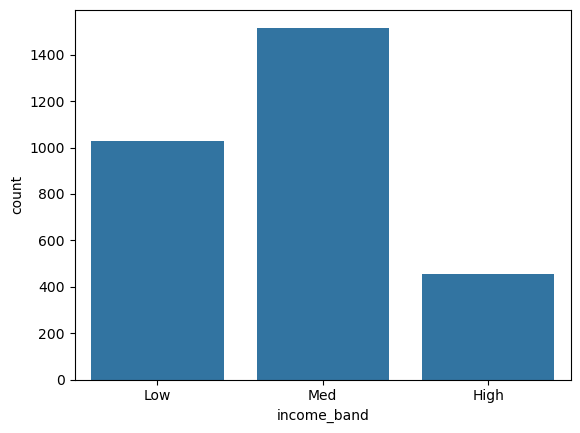

In [46]:
for i, predictor in enumerate(df[[ 'nationality', 'occupation', 'fee_structure',
                                   'loyalty_classification', 'amount_of_credit_cards',
                                   'properties_owned','risk_weighting', 'br_id', 'gender_id', 
                                   'ia_id','income_band']].columns):
    plt.figure(i)
    sns.countplot(data=df, x=predictor)

## Bivariate Analysis

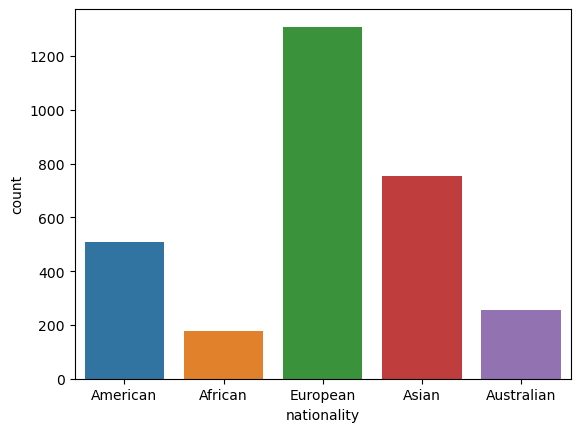

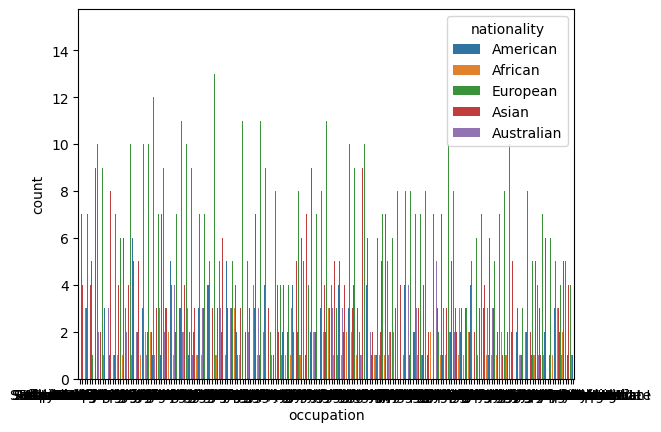

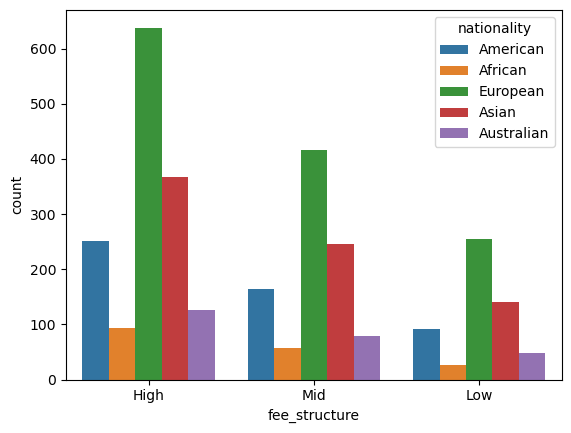

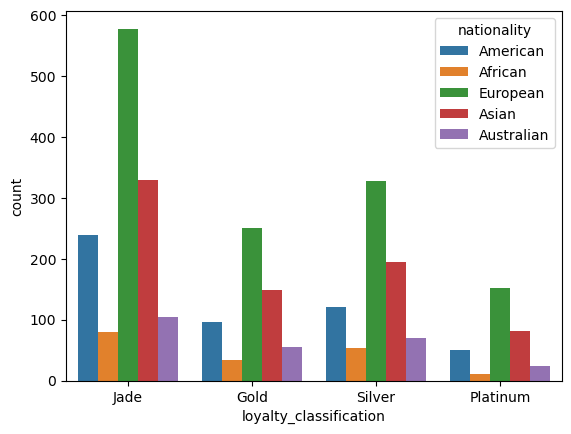

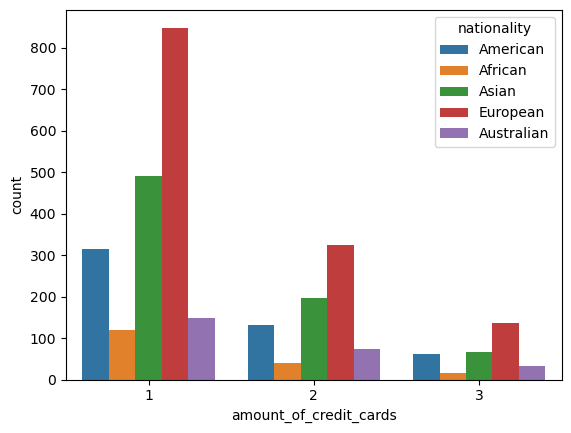

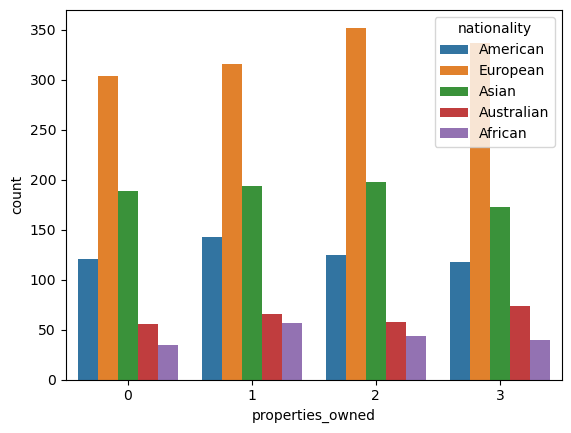

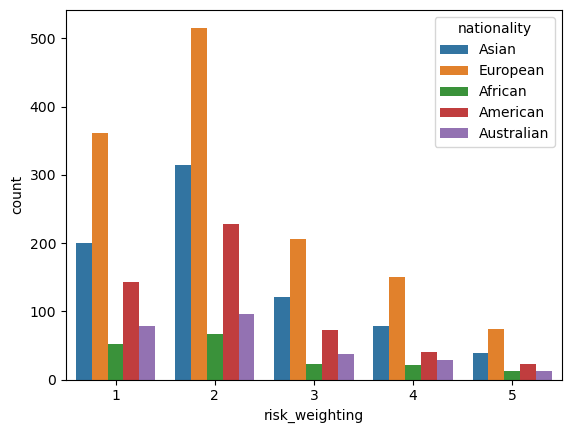

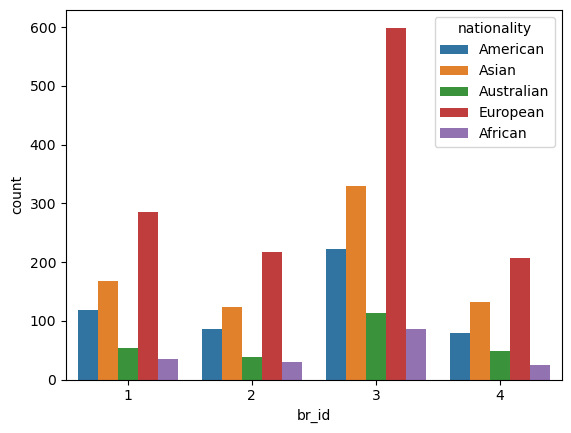

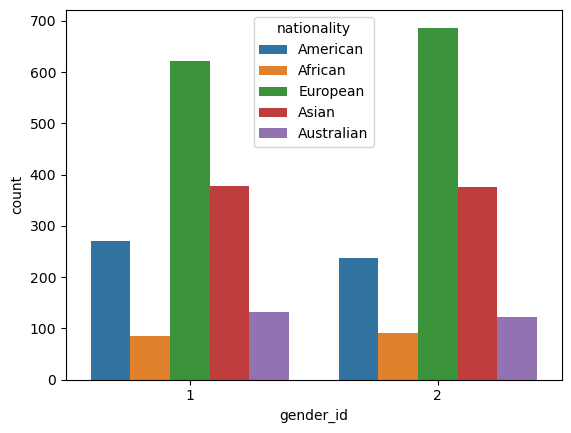

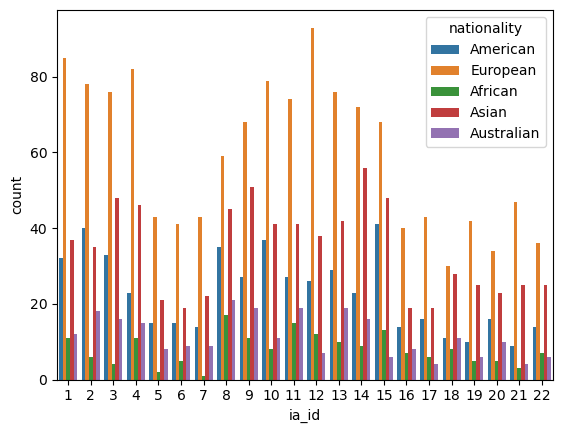

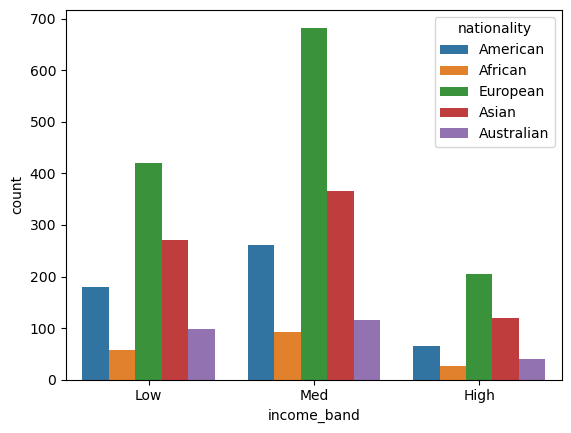

In [47]:
for i, predictor in enumerate(df[[ 'nationality', 'occupation', 'fee_structure',
                                   'loyalty_classification', 'amount_of_credit_cards',
                                   'properties_owned','risk_weighting', 'br_id', 'gender_id', 
                                   'ia_id','income_band']].columns):
    plt.figure(i)
    sns.countplot(data=df, x=predictor,hue='nationality')

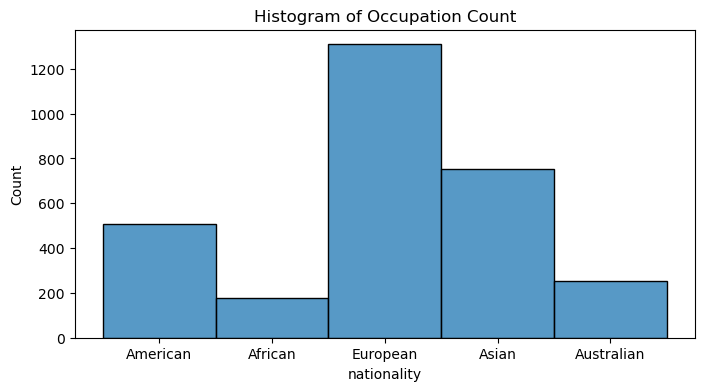

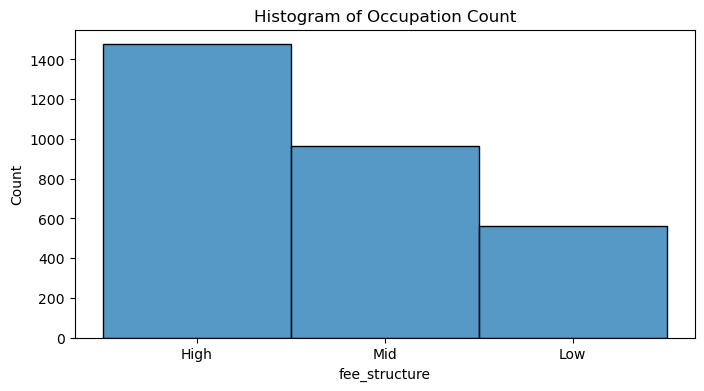

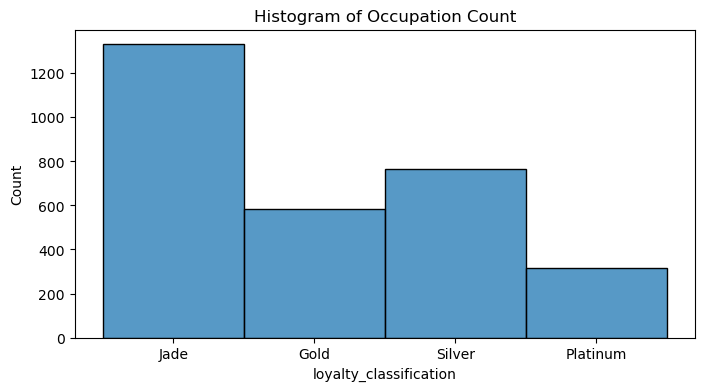

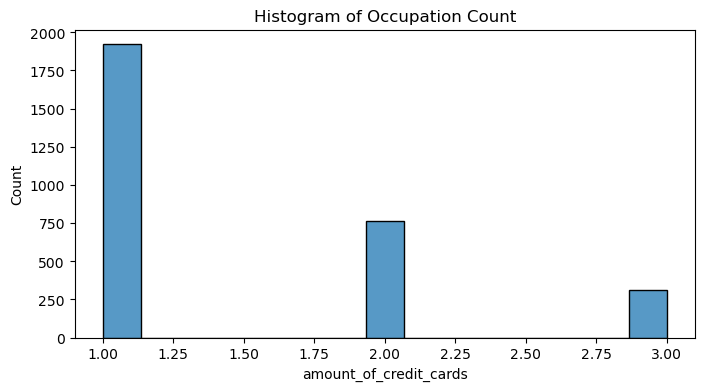

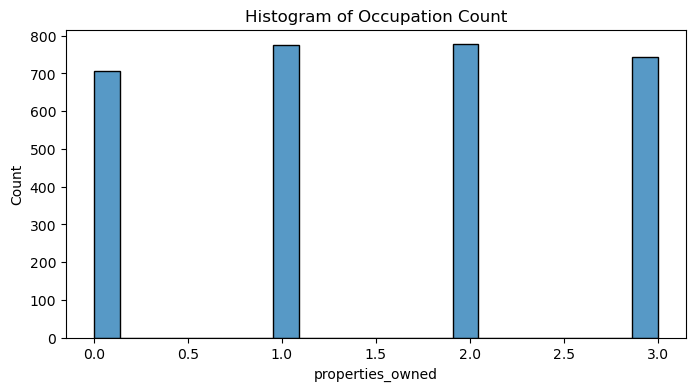

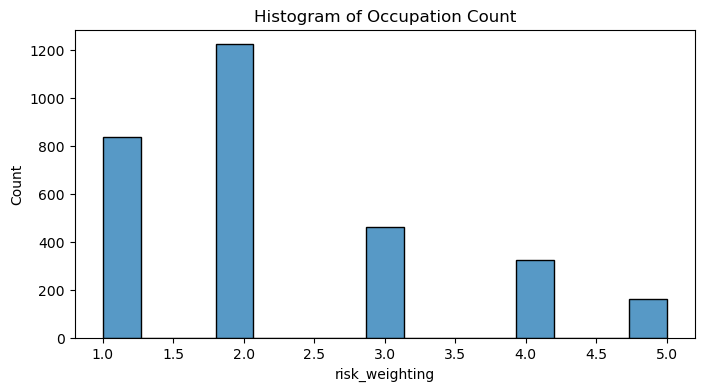

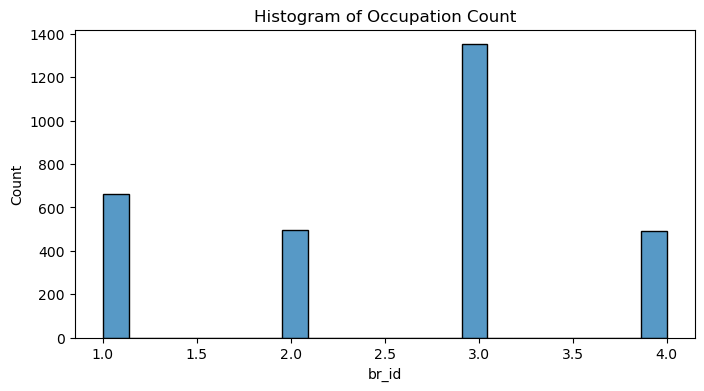

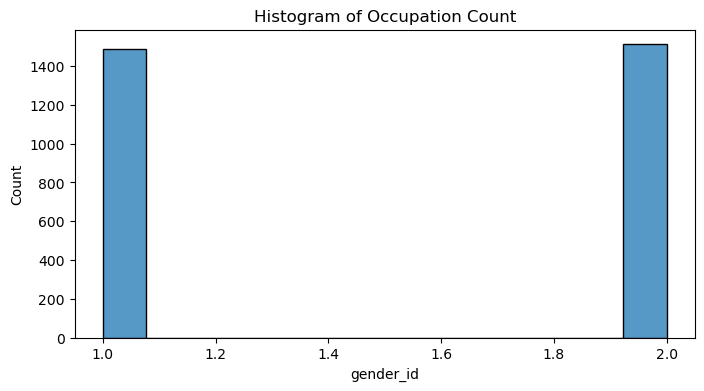

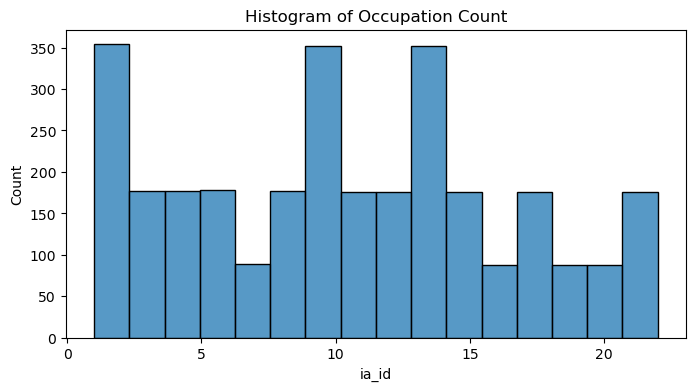

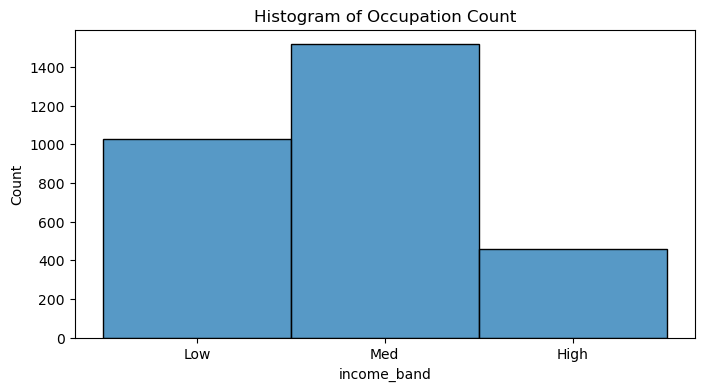

In [48]:
# Hisplot of value counts for different occupation

for col in categorical_cols:
    if col == 'occupation':
        continue
    plt.figure(figsize=(8,4))
    sns.histplot(df[col])
    plt.title('Histogram of Occupation Count')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

## Numerical Analysis

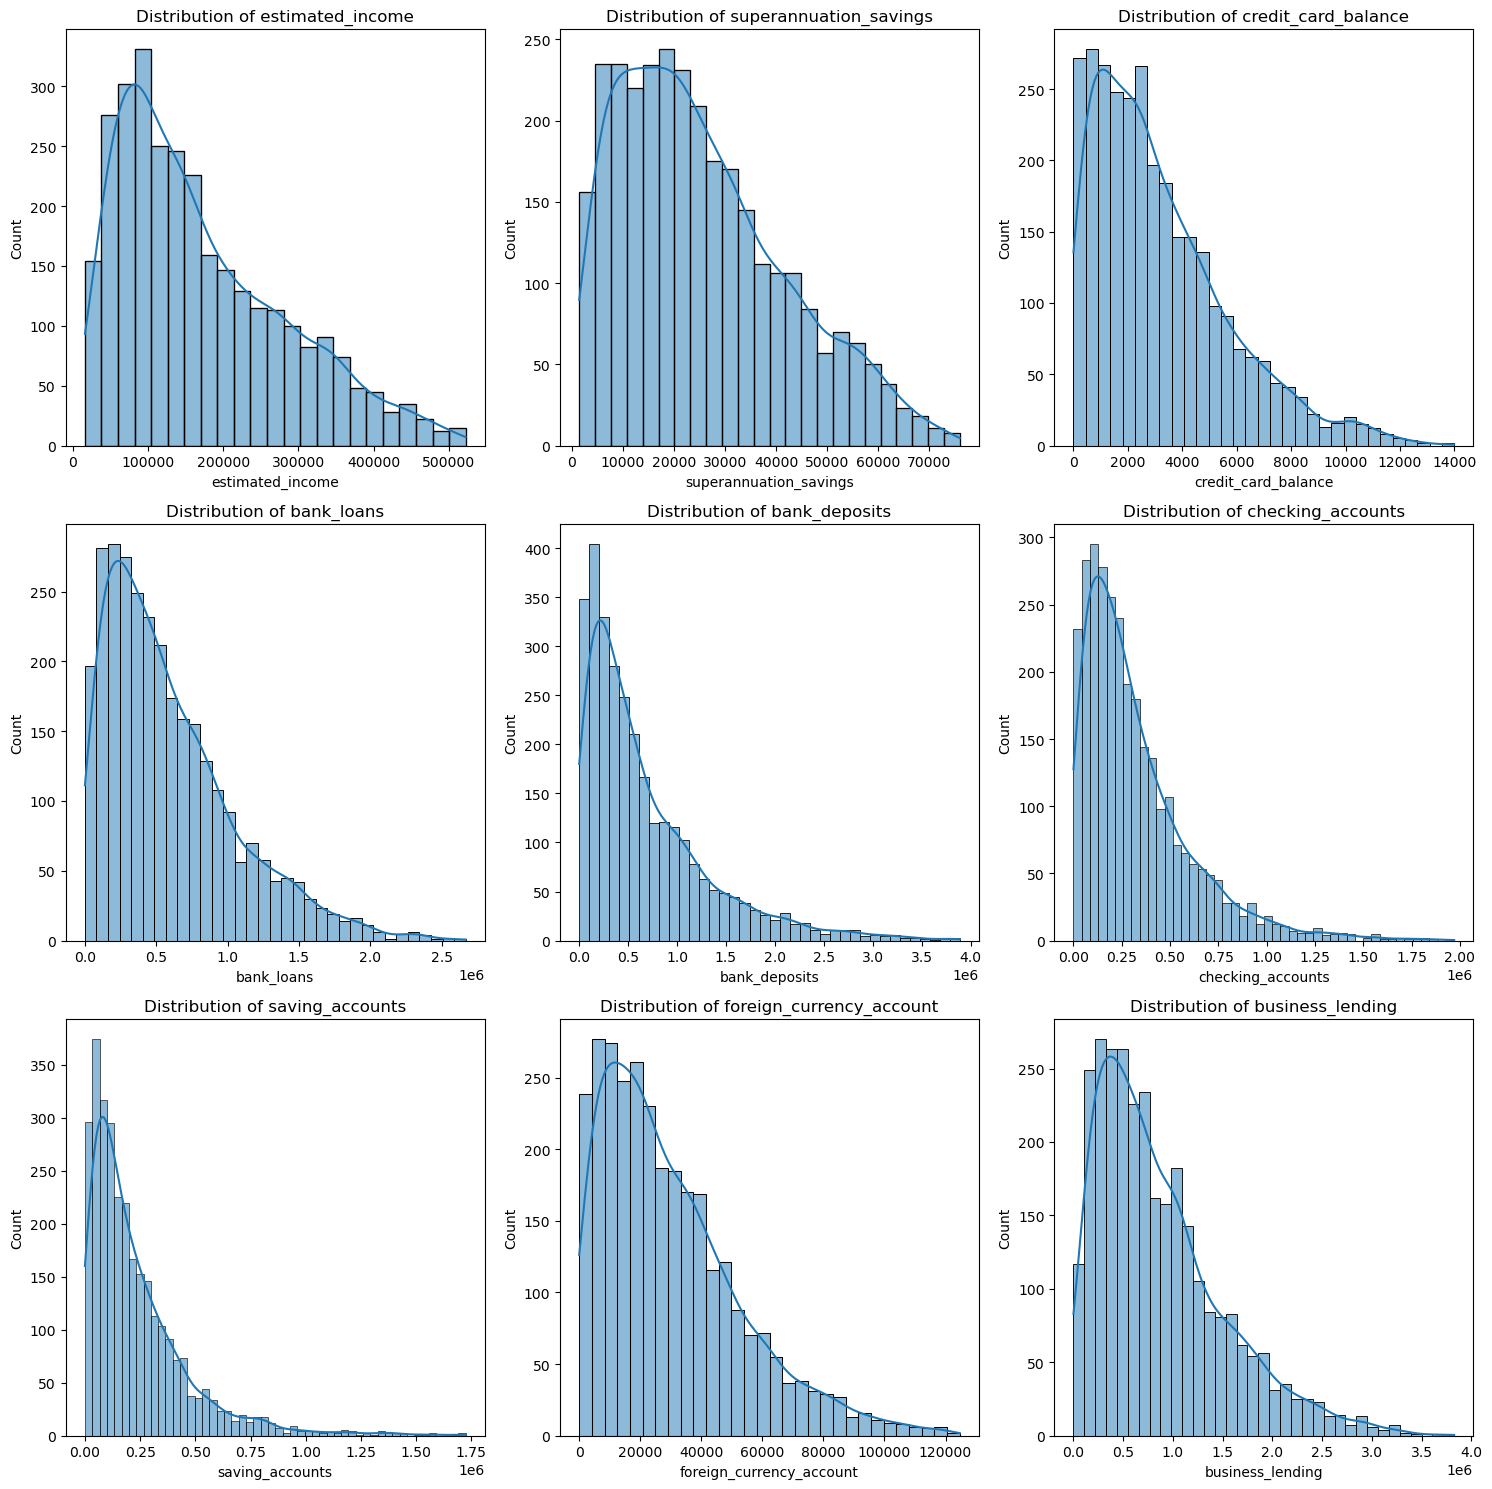

In [50]:
import math

numerical_cols = ['estimated_income','superannuation_savings',
                  'credit_card_balance','bank_loans','bank_deposits',
                  'checking_accounts','saving_accounts',
                  'foreign_currency_account','business_lending']

# Univariate analysis and visualization

# Number of plots
n = len(numerical_cols)
rows = math.ceil(n/3)   # 3 plots per row → 4 rows for 10 columns

plt.figure(figsize=(15, 5*rows))   # adjust figure size

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, 3, i)        # rows × 3 grid
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()


## Heatmaps

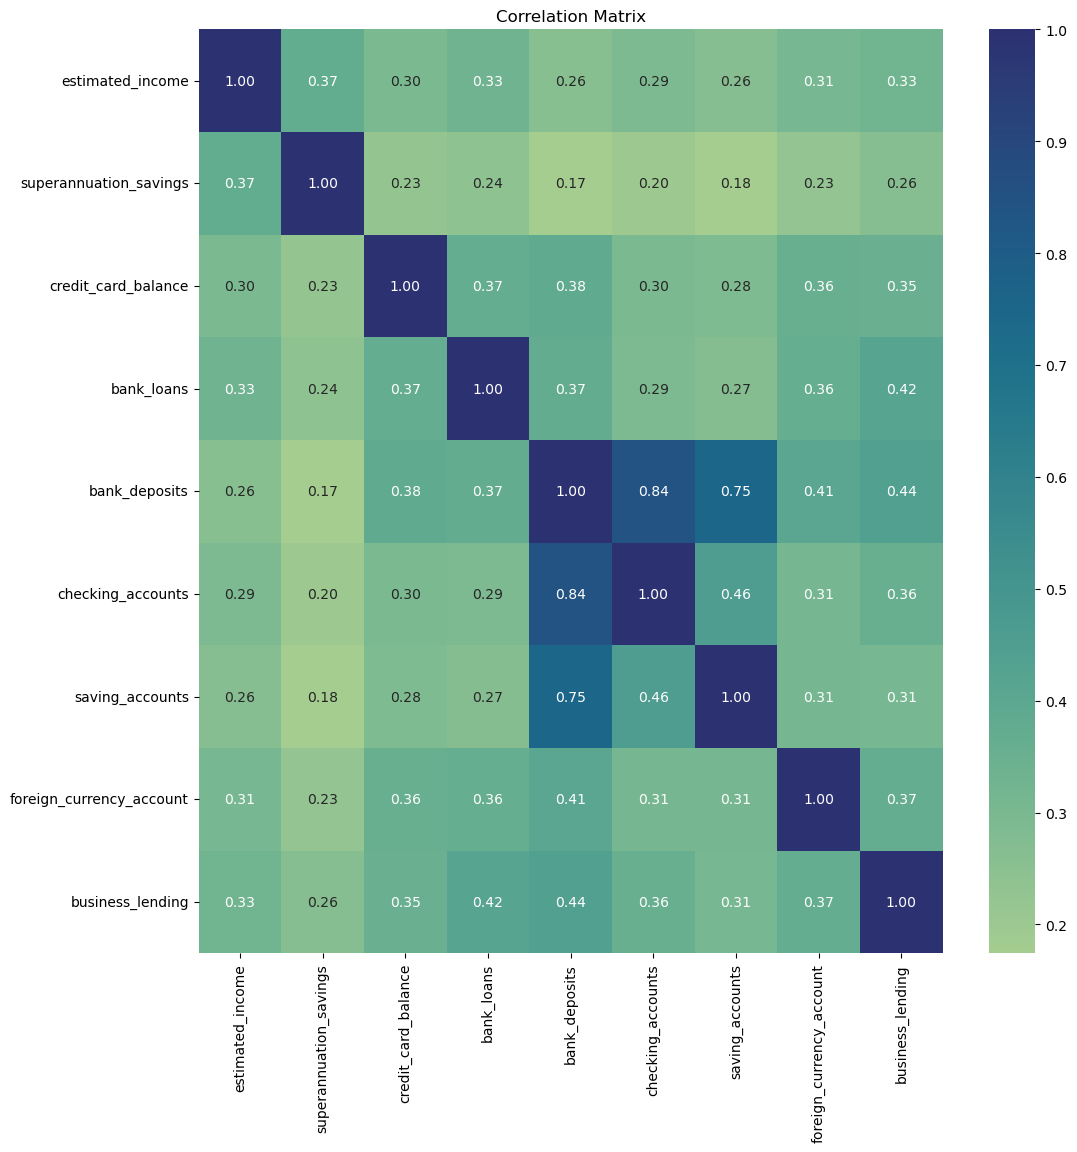

In [51]:
numerical_cols = ['estimated_income','superannuation_savings',
                  'credit_card_balance','bank_loans','bank_deposits',
                  'checking_accounts','saving_accounts',
                  'foreign_currency_account','business_lending']

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12,12))
sns.heatmap(correlation_matrix,annot=True,cmap='crest',fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## Insights of EDA:

#### 1. The strongest positive correlation occur among "Bank Deposits" with "Checking Accounts", "Saving Accounts" and "Foregin Currency Account" indicating that customers who maintain high balances in one account type often hold substantial amount/funds across other accounts as well.